In [43]:

# ADS-505 Group Project: Rossmann Store Sales
# Part 2 :Feature engineering, promotion effectiveness analysis by store type/season/holidays/competition, feature selection, train/validation/test split
# Author : Danitza Loya


In [44]:
# Import libraries

# Data manipulation & operations
import pandas as pd
import numpy as np

# Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# Plots professional appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


In [45]:

# Load the cleaned rossman dataset
df = pd.read_csv("rossmann_cleaned.csv")
df.head()


/var/folders/45/gzz0zc792b1dkfhp2g6rw8ph0000gn/T/ipykernel_18731/2480153459.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("rossmann_cleaned.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31


This preview of the cleaned dataset to confirm the cleaned data loaded correctly. Part 1 highlighted that sales depend on calendar patterns (seasons), store type, holidays and competition influences. These features help us analyze how effective and accurate are promotions through analysis. 


# 1. Feature engineering 

New variables are created: month, season, weekend, promo flags and competition groups. These new variables could help us understand patterns in sales.


In [46]:

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"]) 


In [47]:

# Calendar features
df["Month"] = df["Date"].dt.month # captures seasons' effect
df["Day"] = df["Date"].dt.day
df["Year"] = df["Date"].dt.year # yearly patterns
df["WeekOfYear"] = df["Date"].dt.isocalendar().week
df["IsWeekend"] = df["Date"].dt.dayofweek >= 5 # weekend shopping behavior


In [48]:

# Feature groups seasons by month
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)


In [49]:

# Feature for promotion into a binary indicator
df["PromoFlag"] = (df["Promo"] == 1).astype(int) # promo flag : 1 /  no promo flag : 0


In [50]:

# Competition distance buckets (meaningful ranges)
df["CompetitionGroup"] = pd.cut(
    df["CompetitionDistance"],
    bins=[0, 1000, 5000, 20000, df["CompetitionDistance"].max()],
    labels=["<1km", "1-5km", "5-20km", ">20km"]
)

df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,Year,Month,WeekOfYear,Day,IsWeekend,Season,PromoFlag,CompetitionGroup
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,NaN,NaN,2015,7,31,31,False,Summer,1,1-5km
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,False,Summer,1,<1km
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,False,Summer,1,5-20km
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,NaN,NaN,2015,7,31,31,False,Summer,1,<1km
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,NaN,NaN,2015,7,31,31,False,Summer,1,>20km



# 2. Compare sales on promotion vs non‑promotion


Average Sales (Promo vs No Promo):
PromoFlag
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


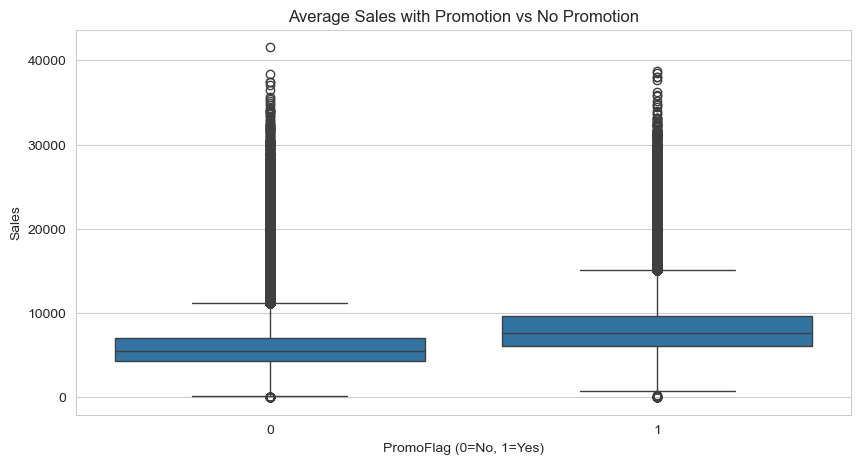

In [51]:

# Compare days with promotion over days without promotion
promo_compare = df.groupby("PromoFlag")["Sales"].mean()
print("Average Sales (Promo vs No Promo):")
print(promo_compare)

# Visualization
sns.boxplot(x="PromoFlag", y="Sales", data=df)
plt.title("Average Sales with Promotion vs No Promotion")
plt.xlabel("PromoFlag (0=No, 1=Yes)")
plt.show()


Interpretation: The box plot on the left labeled as no promotion shows a total of 5,929 average sales without promotion. The box plot on the right labeled as promotion shows an average of 8,228 average sales. The box plot visualizes how sales distribution differ between promo and no promo days. This boxplot  comparison aligns with findings from part 1. There is a strong promotion lift of approximately 39% when promotion is active. 


# 3. Promotion effectiveness 

Promotions might now work equally across different stores, so this section examines how promotion varies across store type, season, month, state or school holidays, competition distance.


In [52]:

# Store type
promo_store = df.groupby(["StoreType", "PromoFlag"])["Sales"].mean()
print("Promo Effect by Store Type:\n", promo_store)


Promo Effect by Store Type:
 StoreType  PromoFlag
a          0             5808.500091
           1             8304.102317
b          0             9566.861686
           1            11307.994108
c          0             6028.063255
           1             8041.995526
d          0             5855.268289
           1             8017.828656
Name: Sales, dtype: float64


Interpretation: "store type b" distinclty shows the highest baseline and promo lift. 

In [53]:

# Season
promo_season = df.groupby(["Season", "PromoFlag"])["Sales"].mean()
print("\nPromo Effect by Season:\n", promo_season)



Promo Effect by Season:
 Season  PromoFlag
Fall    0            5860.818213
        1            7918.724241
Spring  0            5986.206813
        1            8258.128648
Summer  0            5779.935029
        1            8268.701134
Winter  0            6063.889469
        1            8381.741491
Name: Sales, dtype: float64


Interpretation: "Winter season" with promotion shows the highest promo lift.

In [54]:

# Month
promo_month = df.groupby(["Month", "PromoFlag"])["Sales"].mean()
print("\nPromo Effect by Month:\n", promo_month)



Promo Effect by Month:
 Month  PromoFlag
1      0             5591.904236
       1             7782.800277
2      0             5747.812834
       1             7772.909263
3      0             5805.723545
       1             8252.983345
4      0             5855.305439
       1             8426.029528
5      0             6300.749699
       1             8087.946860
6      0             5871.747172
       1             8508.684577
7      0             5751.911514
       1             8257.588809
8      0             5680.220869
       1             7926.496229
9      0             5528.634084
       1             7916.399032
10     0             5845.745508
       1             7646.399697
11     0             6257.749173
       1             8163.897052
12     0             7318.434182
       1            10490.790244
Name: Sales, dtype: float64


Interpretation: "Month 12" (December) has approximately 10490 which is the strongest seasonal lift .

In [55]:

# State Holidays
promo_stateholiday = df.groupby(["StateHoliday", "PromoFlag"])["Sales"].mean()
print("\nPromo Effect by State Holiday:\n", promo_stateholiday)



Promo Effect by State Holiday:
 StateHoliday  PromoFlag
0             0             5778.538267
              1             7987.822376
              0             6012.007268
              1             8345.629535
a             0             8126.837662
              1             8775.230570
b             0             7947.210526
              1            13575.180000
c             0             9743.746479
Name: Sales, dtype: float64


Interpretation: State holidays increase sales but state holidays show the highest lift: type b and type c.

In [56]:

# School Holidays
promo_schoolholiday = df.groupby(["SchoolHoliday", "PromoFlag"])["Sales"].mean()
print("\nPromo Effect by School Holiday:\n", promo_schoolholiday)



Promo Effect by School Holiday:
 SchoolHoliday  PromoFlag
0              0            5876.460707
               1            8199.082281
1              0            6165.307793
               1            8340.601649
Name: Sales, dtype: float64


Interpretation: Promotion on school holidays also show stronger lift (~8340).

In [57]:

# Competition
promo_comp = df.groupby(["CompetitionGroup", "PromoFlag"])["Sales"].mean()
print("\nPromo Effect by Competition Distance:\n", promo_comp)



Promo Effect by Competition Distance:
 CompetitionGroup  PromoFlag
<1km              0            6235.850056
                  1            8624.984386
1-5km             0            5865.102828
                  1            8039.654586
5-20km            0            5712.382778
                  1            8004.494687
>20km             0            5753.492199
                  1            8477.096325
Name: Sales, dtype: float64


/var/folders/45/gzz0zc792b1dkfhp2g6rw8ph0000gn/T/ipykernel_18731/4149544772.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promo_comp = df.groupby(["CompetitionGroup", "PromoFlag"])["Sales"].mean()


Interpretation: Stores that are closer than 1 km from a competitor show the highest sales, which could likely be because of urban traffic.


# 4. Select variables for modeling (avoid leakage)


This section chooses the variables are useful for predicting sales and most importantly, avoid leakage.

In [58]:

# Chosen predictors for modeling
model_vars = [
    "Store", "DayOfWeek", "Promo", "Month", "Day", "Year",
    "IsWeekend", "Season", "CompetitionDistance", "CompetitionGroup",
    "StoreType", "Assortment", "StateHoliday", "SchoolHoliday"
]

df_model = df[model_vars + ["Sales"]].copy()

# Remove customers variable (leakage)
df_model = df_model.drop(columns=["Customers"], errors="ignore")

df_model.head()


,Store,DayOfWeek,Promo,Month,Day,Year,IsWeekend,Season,CompetitionDistance,CompetitionGroup,StoreType,Assortment,StateHoliday,SchoolHoliday,Sales
0,1,5,1,7,31,2015,False,Summer,1270.0,1-5km,c,a,0,1,5263
1,2,5,1,7,31,2015,False,Summer,570.0,<1km,a,a,0,1,6064
2,3,5,1,7,31,2015,False,Summer,14130.0,5-20km,a,a,0,1,8314
3,4,5,1,7,31,2015,False,Summer,620.0,<1km,c,c,0,1,13995
4,5,5,1,7,31,2015,False,Summer,29910.0,>20km,a,a,0,1,4822


Interpretation: the chosen predicting variables are: store, day0fWeek, Promo, Month, Day, Year, IsWeekend, Season, CompetitionDistance,CompetitionGroup, StoreType, Assortment, StateHoliday and SchoolHoliday.: Customers is the removed variable because it is strongly correlated with sales but not available for future predictions.


# 5. Prepare final modeling dataset


The rows that were missing values were dropped because they were not accidental missing but stuctural as shown in 01_data_cleaning_eda. The rows that were missing entries were located where stores did not have a competitor since they did not have competition open dates. They were also dropped when they did not participate in Promo2. These are not errors; they represent true absence of information.

In [59]:

# Drop missing values
df_model = df_model.dropna()

# Check dataset
print("Final modeling dataset shape:", df_model.shape)
df_model.head()


Final modeling dataset shape: (844392, 15)


,Store,DayOfWeek,Promo,Month,Day,Year,IsWeekend,Season,CompetitionDistance,CompetitionGroup,StoreType,Assortment,StateHoliday,SchoolHoliday,Sales
0,1,5,1,7,31,2015,False,Summer,1270.0,1-5km,c,a,0,1,5263
1,2,5,1,7,31,2015,False,Summer,570.0,<1km,a,a,0,1,6064
2,3,5,1,7,31,2015,False,Summer,14130.0,5-20km,a,a,0,1,8314
3,4,5,1,7,31,2015,False,Summer,620.0,<1km,c,c,0,1,13995
4,5,5,1,7,31,2015,False,Summer,29910.0,>20km,a,a,0,1,4822


After cleaning and features engineering, the dataset shape contains 844392 rows and 15 columns. This dataset is now ready for splitting, validation and test sets. 

# 6. Split into train, validation and test sets (time‑based)

Before splitting the data, we sort by date because sales data is time-dependent. 

In [60]:

# Sort by date to avoid leakage
df_model = df_model.sort_values(["Year", "Month", "Day"])

train_size = int(len(df_model) * 0.7)
val_size = int(len(df_model) * 0.15)

train = df_model.iloc[:train_size]
val = df_model.iloc[train_size:train_size + val_size]
test = df_model.iloc[train_size + val_size:]

# Display splitted dataset shape
print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)


Train: (591074, 15)
Validation: (126658, 15)
Test: (126660, 15)


We splitted the dataset into 70% training, 15% validation and 15% test. This strategy aims to prevent future information leakage into past predictions.

The dataset used in Part 2, rossman_cleaned.csv, has been successfully cleaned, with structural missing values removed. To capture sales patterns, new feature engineered variables were created: Month, Season, IsWeekend, PromoFlag and CompetitionGroup.

# 7. Verification

In [61]:

# Save modeling dataset
df_model.to_csv("rossmann_model_dataset.csv", index=False)  # cleaned and feature-engineered


In [62]:

# Verify saved columns
check = pd.read_csv("rossmann_model_dataset.csv")
check.columns


/var/folders/45/gzz0zc792b1dkfhp2g6rw8ph0000gn/T/ipykernel_18731/427625159.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  check = pd.read_csv("rossmann_model_dataset.csv")


Index(['Store', 'DayOfWeek', 'Promo', 'Month', 'Day', 'Year', 'IsWeekend',
       'Season', 'CompetitionDistance', 'CompetitionGroup', 'StoreType',
       'Assortment', 'StateHoliday', 'SchoolHoliday', 'Sales'],
      dtype='object')

The saved modeling dataset contains only safe, non-leaking predictors and the created feature-engineered variables. This dataset is ready for part 3: modeling, training and evaluation.